# 深層強化学習トレーディングシステム - Bybit BTCUSDT Perpetual

## 主要な改善点
1. **ハイパーパラメータチューニング**: 3つのパラメータセットから最適なものを選択
2. **特徴量エンジニアリング**: 無次元化された定常的な特徴量のみを使用
3. **データリーケージ防止**: 訓練データのみでスケーラーをフィット

## 概要
- **データ**: Bybit BTCUSDT Perpetual 1H (2020-09-01 〜 2025-08-31)
- **手法**: 5分割Walk-Forward Optimization (WFO)
- **アルゴリズム**: PPO (stable-baselines3)
- **評価**: シャープレシオ、最大ドローダウン、累積リターン
- **ベンチマーク**: Buy & Hold戦略との比較
- **取引コスト**: テイカー手数料0.06%

### 実行環境
- Google Colab（GPU推奨）
- 実行時間: 約45-90分（GPUあり）

## 1. セットアップ - ライブラリインストールと初期設定

In [16]:
# 必要なライブラリのインストール
!pip install -q --upgrade pip
!pip install -q stable-baselines3==2.3.2
!pip install -q gymnasium==0.28.1
!pip install -q pandas numpy matplotlib plotly
!pip install -q ta scikit-learn
!pip install -q empyrical==0.5.5

print("✅ ライブラリのインストール完了")

# インポート
import os
import sys
import random
import warnings
import pickle
import json
from typing import Dict, List, Tuple, Optional, Any, Union
from dataclasses import dataclass, field
from datetime import datetime, timedelta
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# テクニカル指標
import ta
from sklearn.preprocessing import StandardScaler, RobustScaler

# 強化学習
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, A2C, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy

# 評価指標
import empyrical as ep

# 警告を抑制
warnings.filterwarnings('ignore')

# 乱数シード固定
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# PyTorchがある場合はシード固定
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# GPU確認
try:
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Device: {device}")
    if device.type == 'cuda':
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
except:
    print("🖥️  Device: CPU")

print("✅ セットアップ完了")

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
✅ ライブラリのインストール完了
🖥️  Device: cpu
✅ セットアップ完了


## 2. データロード - Google DriveまたはUpload

In [17]:
# Google Colab環境の確認
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Google Colab環境を検出")
    
    # オプション1: Google Driveマウント
    from google.colab import drive, files
    
    use_drive = input("Google Driveを使用しますか？ (y/n): ").lower() == 'y'
    
    if use_drive:
        drive.mount('/content/drive')
        # Driveのパスを設定（ユーザーが調整）
        DATA_PATH = '/content/drive/MyDrive/data/bybit_btcusdt_perp_1h_20200901_20250831.pkl'
    else:
        # オプション2: ファイルアップロード
        print("📂 ファイルをアップロードしてください")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
else:
    # ローカル環境
    DATA_PATH = '/Users/aimitmk/Documents/2025_松尾研/深層強化学習/data/bybit_btcusdt_perp_1h_20200901_20250831.pkl'

# パラメータ設定
TAKER_FEE = 0.0000  # 0.06%
ANNUALIZATION = 8760  # 1時間足の年率換算（24*365）
EXECUTION_PRICE = 'next_open'  # 'next_open' or 'next_close'
INITIAL_CAPITAL = 1.0  # 初期資金（正規化）
LEVERAGE = 1.0  # レバレッジ

print(f"\n📁 Data path: {DATA_PATH}")
print(f"💰 Taker fee: {TAKER_FEE*100:.2f}%")
print(f"📊 Execution: {EXECUTION_PRICE}")


📁 Data path: /Users/aimitmk/Documents/2025_松尾研/深層強化学習/data/bybit_btcusdt_perp_1h_20200901_20250831.pkl
💰 Taker fee: 0.00%
📊 Execution: next_open


In [18]:
def load_and_preprocess_data(file_path: str) -> pd.DataFrame:
    """データの読み込みと前処理
    
    Args:
        file_path: データファイルのパス
    
    Returns:
        pd.DataFrame: 前処理済みデータ
    """
    # データ読み込み
    if file_path.endswith('.pkl'):
        df = pd.read_pickle(file_path)
    elif file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")
    
    # 列名の正規化（大文字→小文字）
    df.columns = df.columns.str.lower()
    
    # 必須列の確認
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # datetime列の処理
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime')
    elif 'timestamp' in df.columns:
        if df['timestamp'].dtype == 'int64':
            df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
        else:
            df['datetime'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('datetime')
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("No datetime information found")
    
    # 時系列順にソート
    df = df.sort_index()
    
    # 欠損値の処理
    if df.isnull().sum().sum() > 0:
        print(f"⚠️  Found {df.isnull().sum().sum()} NaN values. Forward filling...")
        df = df.fillna(method='ffill').fillna(method='bfill')
    
    print(f"✅ Loaded data: {len(df):,} rows")
    print(f"📅 Period: {df.index[0]} to {df.index[-1]}")
    print(f"📊 Columns: {list(df.columns)}")
    
    return df

# データ読み込み
try:
    df_raw = load_and_preprocess_data(DATA_PATH)
    print("\n📊 Data Statistics:")
    print(df_raw[['open', 'high', 'low', 'close', 'volume']].describe())
except FileNotFoundError:
    print("❌ ファイルが見つかりません。サンプルデータを生成します...")
    # サンプルデータ生成（デモ用）
    date_range = pd.date_range('2020-09-01', '2025-08-31 23:00:00', freq='1h')
    np.random.seed(SEED)
    
    # ランダムウォークでBTC価格をシミュレート
    returns = np.random.normal(0.0001, 0.01, len(date_range))
    prices = 10000 * np.exp(np.cumsum(returns))
    
    df_raw = pd.DataFrame({
        'open': prices * (1 + np.random.normal(0, 0.001, len(prices))),
        'high': prices * (1 + np.abs(np.random.normal(0, 0.005, len(prices)))),
        'low': prices * (1 - np.abs(np.random.normal(0, 0.005, len(prices)))),
        'close': prices,
        'volume': np.random.lognormal(10, 2, len(prices))
    }, index=date_range)
    
    print("✅ サンプルデータを生成しました")

✅ Loaded data: 43,824 rows
📅 Period: 2020-09-01 00:00:00+00:00 to 2025-08-31 23:00:00+00:00
📊 Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']

📊 Data Statistics:
                open           high            low          close  \
count   43824.000000   43824.000000   43824.000000   43824.000000   
mean    48507.202063   48705.646459   48301.867121   48509.407053   
std     27719.893511   27802.646226   27636.374003   27720.801621   
min      9957.000000   10029.500000    9834.000000    9957.000000   
25%     26817.575000   26871.600000   26738.825000   26817.700000   
50%     42091.750000   42259.750000   41879.000000   42093.000000   
75%     63337.250000   63612.625000   63048.875000   63344.050000   
max    123889.200000  124571.200000  123375.000000  123889.200000   

              volume  
count   43824.000000  
mean     4280.451378  
std      5856.405088  
min        15.628000  
25%      1282.272000  
50%      2483.650000  
75%      4988.203750  
max    170105.7

## 3. 改善された特徴量生成 - 無次元化と定常性

In [19]:
def generate_stationary_features(df: pd.DataFrame) -> pd.DataFrame:
    """定常的で無次元化された特徴量を生成
    
    Args:
        df: OHLCVデータ
    
    Returns:
        pd.DataFrame: 特徴量付きデータ
    """
    df = df.copy()
    
    # ===== リターン（無次元化済み） =====
    df['ret_1h'] = df['close'].pct_change()
    df['ret_4h'] = df['close'].pct_change(4)
    df['ret_12h'] = df['close'].pct_change(12)
    df['ret_24h'] = df['close'].pct_change(24)
    df['ret_48h'] = df['close'].pct_change(48)
    
    # ===== ボラティリティ（標準偏差は無次元） =====
    df['vol_24h'] = df['ret_1h'].rolling(24).std()
    df['vol_72h'] = df['ret_1h'].rolling(72).std()
    df['vol_168h'] = df['ret_1h'].rolling(168).std()  # 1週間
    
    # ボラティリティの変化率
    df['vol_ratio_24_72'] = df['vol_24h'] / df['vol_72h'].replace(0, np.nan)
    df['vol_ratio_24_168'] = df['vol_24h'] / df['vol_168h'].replace(0, np.nan)
    
    # ===== RSI（0-100の範囲、無次元） =====
    df['rsi_14'] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
    df['rsi_30'] = ta.momentum.RSIIndicator(close=df['close'], window=30).rsi()
    df['rsi_7'] = ta.momentum.RSIIndicator(close=df['close'], window=7).rsi()
    
    # RSIを0-1の範囲に正規化
    df['rsi_14'] = df['rsi_14'] / 100
    df['rsi_30'] = df['rsi_30'] / 100
    df['rsi_7'] = df['rsi_7'] / 100
    
    # ===== MACD（正規化版） =====
    macd = ta.trend.MACD(close=df['close'], window_slow=26, window_fast=12, window_sign=9)
    df['macd_diff_normalized'] = macd.macd_diff() / df['close']  # 価格で正規化
    df['macd_signal_normalized'] = macd.macd_signal() / df['close']
    
    # ===== ボリンジャーバンド（無次元化） =====
    bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
    bb_high = bb.bollinger_hband()
    bb_low = bb.bollinger_lband()
    bb_mid = bb.bollinger_mavg()
    
    # BBポジション（0-1の範囲）
    df['bb_position'] = (df['close'] - bb_low) / (bb_high - bb_low).replace(0, np.nan)
    df['bb_position'] = df['bb_position'].clip(0, 1)  # 0-1にクリップ
    
    # BB幅（相対値）
    df['bb_width'] = (bb_high - bb_low) / bb_mid
    
    # ===== ATR（正規化版） =====
    atr = ta.volatility.AverageTrueRange(
        high=df['high'], low=df['low'], close=df['close'], window=14
    ).average_true_range()
    df['atr_normalized'] = atr / df['close']  # 価格で正規化
    
    # ===== ボリューム指標（比率ベース、無次元） =====
    df['volume_ratio_24h'] = df['volume'] / df['volume'].rolling(24).mean().replace(0, np.nan)
    df['volume_ratio_168h'] = df['volume'] / df['volume'].rolling(168).mean().replace(0, np.nan)
    df['volume_trend'] = df['volume'].rolling(24).mean() / df['volume'].rolling(168).mean().replace(0, np.nan)
    
    # ===== 価格の相対的な位置（無次元） =====
    # High-Low-Close関係
    df['hl_ratio'] = (df['high'] - df['low']) / df['close']
    df['hc_ratio'] = (df['high'] - df['close']) / df['close']
    df['lc_ratio'] = (df['close'] - df['low']) / df['close']
    
    # ===== 移動平均からの乖離（％表示、無次元） =====
    sma_20 = ta.trend.sma_indicator(df['close'], window=20)
    sma_50 = ta.trend.sma_indicator(df['close'], window=50)
    df['deviation_sma20'] = (df['close'] - sma_20) / sma_20
    df['deviation_sma50'] = (df['close'] - sma_50) / sma_50
    
    # ===== 時間特徴（周期性、無次元） =====
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # ===== Stochastic Oscillator（0-1の範囲） =====
    stoch = ta.momentum.StochasticOscillator(
        high=df['high'], low=df['low'], close=df['close'], 
        window=14, smooth_window=3
    )
    df['stoch_k'] = stoch.stoch() / 100  # 0-1に正規化
    df['stoch_d'] = stoch.stoch_signal() / 100  # 0-1に正規化
    
    # ===== 将来情報リーク防止: すべての特徴量を1期シフト =====
    feature_cols = [col for col in df.columns if col not in ['open', 'high', 'low', 'close', 'volume', 'timestamp']]
    for col in feature_cols:
        df[col] = df[col].shift(1)
    
    # NaN処理（欠損値を0で埋める前に、無限値を処理）
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # NaN削除（最初の200行程度）
    df = df.dropna()
    
    # 特徴量リスト（時間関連の生の値を除外）
    feature_cols = [col for col in feature_cols if col not in ['hour', 'dayofweek']]
    
    print(f"✅ Generated {len(feature_cols)} stationary features")
    print(f"📊 Final shape: {df.shape}")
    
    # 特徴量の統計情報を確認
    print("\n📈 Feature statistics (mean, std):")
    for col in feature_cols[:5]:  # 最初の5つの特徴量を表示
        mean_val = df[col].mean()
        std_val = df[col].std()
        print(f"   {col}: mean={mean_val:.4f}, std={std_val:.4f}")
    
    return df, feature_cols

# 特徴量生成
df_features, feature_columns = generate_stationary_features(df_raw)
print(f"\n📋 Feature columns ({len(feature_columns)}):")
for i in range(0, len(feature_columns), 5):
    print(f"   {feature_columns[i:i+5]}")

✅ Generated 32 stationary features
📊 Final shape: (43655, 40)

📈 Feature statistics (mean, std):
   ret_1h: mean=0.0001, std=0.0065
   ret_4h: mean=0.0003, std=0.0128
   ret_12h: mean=0.0009, std=0.0220
   ret_24h: mean=0.0018, std=0.0315
   ret_48h: mean=0.0036, std=0.0439

📋 Feature columns (32):
   ['ret_1h', 'ret_4h', 'ret_12h', 'ret_24h', 'ret_48h']
   ['vol_24h', 'vol_72h', 'vol_168h', 'vol_ratio_24_72', 'vol_ratio_24_168']
   ['rsi_14', 'rsi_30', 'rsi_7', 'macd_diff_normalized', 'macd_signal_normalized']
   ['bb_position', 'bb_width', 'atr_normalized', 'volume_ratio_24h', 'volume_ratio_168h']
   ['volume_trend', 'hl_ratio', 'hc_ratio', 'lc_ratio', 'deviation_sma20']
   ['deviation_sma50', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
   ['stoch_k', 'stoch_d']


## 4. データ分割 - Train/Test & Walk-Forward

In [20]:
def split_data(df: pd.DataFrame, train_ratio: float = 5/6) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """データをTrain/Testに分割
    
    Args:
        df: 特徴量付きデータ
        train_ratio: 学習データの割合（デフォルト5/6）
    
    Returns:
        tuple: (train_df, test_df)
    """
    n = len(df)
    train_size = int(n * train_ratio)
    
    train_df = df.iloc[:train_size].copy()
    test_df = df.iloc[train_size:].copy()
    
    print(f"📊 Data Split:")
    print(f"   Train: {len(train_df):,} rows ({train_df.index[0]} to {train_df.index[-1]})")
    print(f"   Test:  {len(test_df):,} rows ({test_df.index[0]} to {test_df.index[-1]})")
    print(f"   Ratio: {len(train_df)/n:.1%} / {len(test_df)/n:.1%}")
    
    return train_df, test_df

def create_walk_forward_splits(train_df: pd.DataFrame, n_splits: int = 5) -> List[Tuple[pd.DataFrame, pd.DataFrame]]:
    """Walk-Forward用の分割を作成（ローリング方式）
    
    Args:
        train_df: 学習データ
        n_splits: 分割数
    
    Returns:
        list: [(train_fold, val_fold), ...]
    """
    n = len(train_df)
    fold_size = n // n_splits
    
    splits = []
    for i in range(n_splits - 1):  # 最後の1つは検証用なので n_splits-1
        # ローリング拡張: 開始から fold*(i+1) までを学習
        train_end = fold_size * (i + 1)
        val_start = train_end
        val_end = val_start + fold_size
        
        train_fold = train_df.iloc[:train_end].copy()
        val_fold = train_df.iloc[val_start:val_end].copy()
        
        splits.append((train_fold, val_fold))
        
        print(f"\n📁 WFO Split {i+1}:")
        print(f"   Train: {len(train_fold):,} rows ({train_fold.index[0]} to {train_fold.index[-1]})")
        print(f"   Val:   {len(val_fold):,} rows ({val_fold.index[0]} to {val_fold.index[-1]})")
    
    return splits

# データ分割
train_df, test_df = split_data(df_features, train_ratio=5/6)

# Walk-Forward分割
print("\n🔄 Creating Walk-Forward splits...")
wfo_splits = create_walk_forward_splits(train_df, n_splits=5)

📊 Data Split:
   Train: 36,379 rows (2020-09-08 01:00:00+00:00 to 2024-11-01 19:00:00+00:00)
   Test:  7,276 rows (2024-11-01 20:00:00+00:00 to 2025-08-31 23:00:00+00:00)
   Ratio: 83.3% / 16.7%

🔄 Creating Walk-Forward splits...

📁 WFO Split 1:
   Train: 7,275 rows (2020-09-08 01:00:00+00:00 to 2021-07-08 03:00:00+00:00)
   Val:   7,275 rows (2021-07-08 04:00:00+00:00 to 2022-05-07 06:00:00+00:00)

📁 WFO Split 2:
   Train: 14,550 rows (2020-09-08 01:00:00+00:00 to 2022-05-07 06:00:00+00:00)
   Val:   7,275 rows (2022-05-07 07:00:00+00:00 to 2023-03-06 09:00:00+00:00)

📁 WFO Split 3:
   Train: 21,825 rows (2020-09-08 01:00:00+00:00 to 2023-03-06 09:00:00+00:00)
   Val:   7,275 rows (2023-03-06 10:00:00+00:00 to 2024-01-03 12:00:00+00:00)

📁 WFO Split 4:
   Train: 29,100 rows (2020-09-08 01:00:00+00:00 to 2024-01-03 12:00:00+00:00)
   Val:   7,275 rows (2024-01-03 13:00:00+00:00 to 2024-11-01 15:00:00+00:00)


## 5. 改善されたトレーディング環境 - データリーケージ防止

In [21]:
class ImprovedCryptoTradingEnv(gym.Env):
    """データリーケージを防ぐ改善されたトレーディング環境
    
    連続アクション: -1（フルショート）〜 +1（フルロング）
    """
    
    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        initial_capital: float = 1.0,
        taker_fee: float = 0.0006,
        leverage: float = 1.0,
        execution_price: str = 'next_close',
        scaler: Optional[StandardScaler] = None,
        fit_scaler: bool = False
    ):
        super().__init__()
        
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.initial_capital = initial_capital
        self.taker_fee = taker_fee
        self.leverage = leverage
        self.execution_price = execution_price
        
        # スケーラーの管理（データリーケージ防止）
        if fit_scaler:
            # 訓練データの場合: 新しいスケーラーをfitする
            self.scaler = RobustScaler()  # 外れ値に強いRobustScalerを使用
            self.features_scaled = self.scaler.fit_transform(self.df[feature_cols].values)
        elif scaler is not None:
            # 検証/テストデータの場合: 訓練データのスケーラーを使用
            self.scaler = scaler
            self.features_scaled = self.scaler.transform(self.df[feature_cols].values)
        else:
            raise ValueError("Either fit_scaler must be True or scaler must be provided")
        
        # アクション空間: 連続値（ターゲットポジション -1〜+1）
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        
        # 観測空間: 特徴量 + ポジション + PnL
        n_features = len(feature_cols) + 2  # +2 for position and pnl
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(n_features,), dtype=np.float32
        )
        
        # 内部状態
        self.reset()
    
    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """環境をリセット"""
        super().reset(seed=seed)
        
        self.current_step = 0
        self.position = 0.0  # -1〜+1
        self.capital = self.initial_capital
        self.nav = self.initial_capital  # Net Asset Value
        self.pnl = 0.0
        
        # 履歴記録
        self.nav_history = [self.nav]
        self.position_history = [self.position]
        self.trades = []
        self.returns = []
        
        return self._get_observation(), {}
    
    def _get_observation(self):
        """現在の観測値を取得"""
        if self.current_step >= len(self.df) - 1:
            return np.zeros(self.observation_space.shape[0], dtype=np.float32)
        
        # 特徴量（既にスケーリング済み）
        features = self.features_scaled[self.current_step]
        
        # ポジションとPnL（これらも-1〜1の範囲に正規化）
        position_feature = np.array([self.position])
        pnl_feature = np.array([np.clip(self.pnl / self.initial_capital, -1, 1)])  # -100%〜+100%にクリップ
        
        # 結合
        obs = np.concatenate([features, position_feature, pnl_feature])
        
        return obs.astype(np.float32)
    
    def step(self, action: np.ndarray):
        """環境を1ステップ進める"""
        if self.current_step >= len(self.df) - 2:
            return self._get_observation(), 0, True, False, {}
        
        # アクションをクリップ（-1〜+1）
        target_position = np.clip(action[0], -1, 1)
        
        # 現在と次の価格を取得
        current_price = self.df.iloc[self.current_step]['close']
        
        if self.execution_price == 'next_close':
            next_price = self.df.iloc[self.current_step + 1]['close']
        else:  # next_open
            next_price = self.df.iloc[self.current_step + 1]['open']
        
        # リターンを計算
        price_return = (next_price - current_price) / current_price
        
        # ポジション変更のコスト
        position_change = abs(target_position - self.position)
        trade_cost = self.taker_fee * position_change
        
        # ポートフォリオリターン = ポジション × 価格リターン - 取引コスト
        portfolio_return = self.position * price_return * self.leverage - trade_cost
        
        # NAV更新
        self.nav = self.nav * (1 + portfolio_return)
        self.pnl = self.nav - self.initial_capital
        
        # 報酬関数の改善: シャープレシオベース
        self.returns.append(portfolio_return)
        if len(self.returns) > 24:  # 直近24時間のシャープレシオ
            recent_returns = self.returns[-24:]
            mean_return = np.mean(recent_returns)
            std_return = np.std(recent_returns)
            if std_return > 0:
                sharpe_24h = mean_return / std_return
                reward = portfolio_return + 0.01 * sharpe_24h  # リターン + シャープレシオボーナス
            else:
                reward = portfolio_return
        else:
            reward = portfolio_return
        
        # ポジション更新
        if position_change > 0.01:  # 最小変更閾値
            self.trades.append({
                'step': self.current_step,
                'datetime': self.df.index[self.current_step] if hasattr(self.df, 'index') else self.current_step,
                'action': target_position,
                'position_before': self.position,
                'position_after': target_position,
                'price': next_price,
                'cost': trade_cost
            })
        
        self.position = target_position
        
        # 履歴記録
        self.nav_history.append(self.nav)
        self.position_history.append(self.position)
        
        # ステップを進める
        self.current_step += 1
        
        # 終了判定
        done = self.current_step >= len(self.df) - 2
        
        # 破産判定
        if self.nav < self.initial_capital * 0.1:  # 90%損失で終了
            done = True
            reward = -1  # ペナルティ
        
        # 情報
        info = {
            'nav': self.nav,
            'pnl': self.pnl,
            'position': self.position,
            'n_trades': len(self.trades)
        }
        
        return self._get_observation(), reward, done, False, info
    
    def get_scaler(self):
        """スケーラーを取得（他の環境で再利用するため）"""
        return self.scaler
    
    def render(self, mode='human'):
        """環境の描画（オプション）"""
        pass

# 環境のテスト
print("🎮 Testing improved trading environment...")
test_env = ImprovedCryptoTradingEnv(
    df=train_df.iloc[:1000],
    feature_cols=feature_columns,
    taker_fee=TAKER_FEE,
    fit_scaler=True  # 訓練データなのでfitする
)
obs, _ = test_env.reset()
print(f"✅ Environment created")
print(f"   Observation shape: {obs.shape}")
print(f"   Action space: {test_env.action_space}")
print(f"   Scaler fitted: Yes")

🎮 Testing improved trading environment...
✅ Environment created
   Observation shape: (34,)
   Action space: Box(-1.0, 1.0, (1,), float32)
   Scaler fitted: Yes


## 6. ハイパーパラメータセットの定義

In [22]:
@dataclass
class PPOHyperparameters:
    """PPOハイパーパラメータのセット"""
    name: str
    learning_rate: float
    n_steps: int
    batch_size: int
    n_epochs: int
    gamma: float
    gae_lambda: float
    clip_range: float
    ent_coef: float
    vf_coef: float
    max_grad_norm: float
    policy_kwargs: Dict[str, Any] = field(default_factory=dict)

# 3つの異なるハイパーパラメータセットを定義
HYPERPARAMETER_SETS = [
    PPOHyperparameters(
        name="Conservative",
        learning_rate=1e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        policy_kwargs={'net_arch': [dict(pi=[256, 256], vf=[256, 256])]}
    ),
    PPOHyperparameters(
        name="Moderate",
        learning_rate=3e-4,
        n_steps=1024,
        batch_size=128,
        n_epochs=5,
        gamma=0.98,
        gae_lambda=0.92,
        clip_range=0.3,
        ent_coef=0.02,
        vf_coef=0.4,
        max_grad_norm=0.7,
        policy_kwargs={'net_arch': [dict(pi=[128, 128], vf=[128, 128])]}
    ),
    PPOHyperparameters(
        name="Aggressive",
        learning_rate=5e-4,
        n_steps=512,
        batch_size=256,
        n_epochs=3,
        gamma=0.95,
        gae_lambda=0.9,
        clip_range=0.4,
        ent_coef=0.05,
        vf_coef=0.3,
        max_grad_norm=1.0,
        policy_kwargs={'net_arch': [dict(pi=[64, 64], vf=[64, 64])]}
    )
]

print("📊 Hyperparameter Sets Defined:")
for hp_set in HYPERPARAMETER_SETS:
    print(f"\n🔧 {hp_set.name}:")
    print(f"   Learning Rate: {hp_set.learning_rate}")
    print(f"   N Steps: {hp_set.n_steps}")
    print(f"   Batch Size: {hp_set.batch_size}")
    print(f"   N Epochs: {hp_set.n_epochs}")
    print(f"   Entropy Coef: {hp_set.ent_coef}")

📊 Hyperparameter Sets Defined:

🔧 Conservative:
   Learning Rate: 0.0001
   N Steps: 2048
   Batch Size: 64
   N Epochs: 10
   Entropy Coef: 0.01

🔧 Moderate:
   Learning Rate: 0.0003
   N Steps: 1024
   Batch Size: 128
   N Epochs: 5
   Entropy Coef: 0.02

🔧 Aggressive:
   Learning Rate: 0.0005
   N Steps: 512
   Batch Size: 256
   N Epochs: 3
   Entropy Coef: 0.05


## 7. Walk-Forward Optimization with Hyperparameter Selection

In [23]:
@dataclass
class WFOResult:
    """Walk-Forwardステップの結果"""
    step: int
    hyperparameter_name: str
    train_period: Tuple[str, str]
    val_period: Tuple[str, str]
    train_reward: float
    val_reward: float
    val_sharpe: float
    val_return: float
    val_max_drawdown: float
    n_trades: int
    scaler: Any  # StandardScaler

def train_ppo_model(
    train_env: gym.Env,
    val_env: gym.Env,
    hyperparameters: PPOHyperparameters,
    total_timesteps: int = 50000,
    verbose: int = 0
) -> Tuple[PPO, Dict[str, float]]:
    """PPOモデルの学習
    
    Returns:
        tuple: (trained_model, validation_metrics)
    """
    # DummyVecEnvでラップ
    vec_env = DummyVecEnv([lambda: train_env])
    
    # PPOモデル作成
    model = PPO(
        'MlpPolicy',
        vec_env,
        learning_rate=hyperparameters.learning_rate,
        n_steps=hyperparameters.n_steps,
        batch_size=hyperparameters.batch_size,
        n_epochs=hyperparameters.n_epochs,
        gamma=hyperparameters.gamma,
        gae_lambda=hyperparameters.gae_lambda,
        clip_range=hyperparameters.clip_range,
        ent_coef=hyperparameters.ent_coef,
        vf_coef=hyperparameters.vf_coef,
        max_grad_norm=hyperparameters.max_grad_norm,
        policy_kwargs=hyperparameters.policy_kwargs,
        verbose=verbose,
        seed=SEED,
        device='auto'
    )
    
    # 学習
    model.learn(total_timesteps=total_timesteps)
    
    # 検証
    val_metrics = evaluate_model(model, val_env)
    
    return model, val_metrics

def evaluate_model(model: PPO, env: gym.Env, n_episodes: int = 1) -> Dict[str, float]:
    """モデルの評価
    
    Returns:
        dict: 評価指標
    """
    all_rewards = []
    all_navs = []
    all_trades = []
    
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            episode_reward += reward
        
        all_rewards.append(episode_reward)
        all_navs.extend(env.nav_history)
        all_trades.append(len(env.trades))
    
    # リターン計算
    returns = np.diff(all_navs) / all_navs[:-1] if len(all_navs) > 1 else [0]
    
    # シャープレシオ（時間足）
    if np.std(returns) > 0:
        sharpe = np.sqrt(ANNUALIZATION) * np.mean(returns) / np.std(returns)
    else:
        sharpe = 0
    
    # 累積リターン
    total_return = (all_navs[-1] / all_navs[0] - 1) if len(all_navs) > 0 else 0
    
    # 最大ドローダウン
    cummax = np.maximum.accumulate(all_navs)
    drawdown = (all_navs - cummax) / cummax
    max_drawdown = np.min(drawdown) if len(drawdown) > 0 else 0
    
    return {
        'total_reward': np.mean(all_rewards),
        'sharpe_ratio': sharpe,
        'total_return': total_return,
        'max_drawdown': max_drawdown,
        'n_trades': np.mean(all_trades),
        'final_nav': all_navs[-1] if all_navs else 1.0
    }

def run_walk_forward_with_hyperparameter_selection(
    wfo_splits: List[Tuple[pd.DataFrame, pd.DataFrame]],
    feature_cols: List[str],
    hyperparameter_sets: List[PPOHyperparameters],
    total_timesteps: int = 50000
) -> Tuple[List[Dict[str, List[WFOResult]]], PPOHyperparameters]:
    """Walk-Forward Optimizationを実行し、最良のハイパーパラメータを選択
    
    Returns:
        tuple: (all_results, best_hyperparameters)
    """
    all_results = {hp.name: [] for hp in hyperparameter_sets}
    
    # 各ハイパーパラメータセットでWFOを実行
    for hp_set in hyperparameter_sets:
        print(f"\n" + "="*60)
        print(f"🔧 Testing Hyperparameters: {hp_set.name}")
        print("="*60)
        
        for i, (train_fold, val_fold) in enumerate(wfo_splits):
            print(f"\n📁 WFO Step {i+1}/{len(wfo_splits)} - {hp_set.name}")
            
            # 環境作成（訓練データでスケーラーをfit）
            train_env = ImprovedCryptoTradingEnv(
                df=train_fold,
                feature_cols=feature_cols,
                taker_fee=TAKER_FEE,
                fit_scaler=True
            )
            
            # 訓練データのスケーラーを使って検証環境を作成
            val_env = ImprovedCryptoTradingEnv(
                df=val_fold,
                feature_cols=feature_cols,
                taker_fee=TAKER_FEE,
                scaler=train_env.get_scaler(),
                fit_scaler=False
            )
            
            # 学習
            print(f"   Training on {len(train_fold)} samples...")
            start_time = time.time()
            
            model, val_metrics = train_ppo_model(
                train_env,
                val_env,
                hp_set,
                total_timesteps=total_timesteps,
                verbose=0
            )
            
            train_time = time.time() - start_time
            
            # 結果記録
            result = WFOResult(
                step=i+1,
                hyperparameter_name=hp_set.name,
                train_period=(str(train_fold.index[0]), str(train_fold.index[-1])),
                val_period=(str(val_fold.index[0]), str(val_fold.index[-1])),
                train_reward=0,  # 簡略化
                val_reward=val_metrics['total_reward'],
                val_sharpe=val_metrics['sharpe_ratio'],
                val_return=val_metrics['total_return'],
                val_max_drawdown=val_metrics['max_drawdown'],
                n_trades=int(val_metrics['n_trades']),
                scaler=train_env.get_scaler()
            )
            
            all_results[hp_set.name].append(result)
            
            # 結果表示
            print(f"   Validation Results:")
            print(f"     Sharpe: {val_metrics['sharpe_ratio']:.3f}")
            print(f"     Return: {val_metrics['total_return']*100:.2f}%")
            print(f"     Max DD: {val_metrics['max_drawdown']*100:.2f}%")
            print(f"     Time: {train_time:.1f}s")
    
    # 最良のハイパーパラメータを選択（平均シャープレシオが最高のもの）
    avg_sharpes = {}
    for hp_name, results in all_results.items():
        avg_sharpe = np.mean([r.val_sharpe for r in results])
        avg_sharpes[hp_name] = avg_sharpe
        print(f"\n📊 {hp_name} - Average Sharpe: {avg_sharpe:.3f}")
    
    best_hp_name = max(avg_sharpes, key=avg_sharpes.get)
    best_hp = next(hp for hp in hyperparameter_sets if hp.name == best_hp_name)
    
    print(f"\n🏆 Best Hyperparameters: {best_hp_name} (Avg Sharpe: {avg_sharpes[best_hp_name]:.3f})")
    
    return all_results, best_hp

# Walk-Forward Optimization実行
print("🚀 Starting Walk-Forward Optimization with Hyperparameter Selection...")
print(f"   Total timesteps per fold: 50,000")
print(f"   Algorithm: PPO")
print(f"   Fee: {TAKER_FEE*100:.2f}%")
print(f"   Hyperparameter sets: {len(HYPERPARAMETER_SETS)}")

wfo_all_results, best_hyperparameters = run_walk_forward_with_hyperparameter_selection(
    wfo_splits,
    feature_columns,
    HYPERPARAMETER_SETS,
    total_timesteps=50000  # 実環境では100000以上推奨
)

🚀 Starting Walk-Forward Optimization with Hyperparameter Selection...
   Total timesteps per fold: 50,000
   Algorithm: PPO
   Fee: 0.00%
   Hyperparameter sets: 3

🔧 Testing Hyperparameters: Conservative

📁 WFO Step 1/4 - Conservative
   Training on 7275 samples...
   Validation Results:
     Sharpe: -0.677
     Return: -19.36%
     Max DD: -42.51%
     Time: 19.6s

📁 WFO Step 2/4 - Conservative
   Training on 14550 samples...
   Validation Results:
     Sharpe: 0.741
     Return: 16.18%
     Max DD: -24.38%
     Time: 18.9s

📁 WFO Step 3/4 - Conservative
   Training on 21825 samples...
   Validation Results:
     Sharpe: -1.941
     Return: -28.82%
     Max DD: -32.83%
     Time: 18.7s

📁 WFO Step 4/4 - Conservative
   Training on 29100 samples...
   Validation Results:
     Sharpe: 1.237
     Return: 26.85%
     Max DD: -17.07%
     Time: 18.4s

🔧 Testing Hyperparameters: Moderate

📁 WFO Step 1/4 - Moderate
   Training on 7275 samples...
   Validation Results:
     Sharpe: 0.378
   

## 8. WFO結果サマリー

In [24]:
# WFO結果をDataFrameに変換（各ハイパーパラメータセット）
summary_data = []
for hp_name, results in wfo_all_results.items():
    for r in results:
        summary_data.append({
            'Hyperparameters': hp_name,
            'Step': r.step,
            'Val Sharpe': r.val_sharpe,
            'Val Return (%)': r.val_return * 100,
            'Max DD (%)': r.val_max_drawdown * 100,
            'N Trades': r.n_trades
        })

wfo_summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("📊 Walk-Forward Optimization Results by Hyperparameter Set")
print("="*80)

# 各ハイパーパラメータセットの平均パフォーマンス
for hp_name in [hp.name for hp in HYPERPARAMETER_SETS]:
    hp_data = wfo_summary_df[wfo_summary_df['Hyperparameters'] == hp_name]
    print(f"\n🔧 {hp_name}:")
    print(f"   Avg Sharpe: {hp_data['Val Sharpe'].mean():.3f} ± {hp_data['Val Sharpe'].std():.3f}")
    print(f"   Avg Return: {hp_data['Val Return (%)'].mean():.2f}% ± {hp_data['Val Return (%)'].std():.2f}%")
    print(f"   Avg Max DD: {hp_data['Max DD (%)'].mean():.2f}% ± {hp_data['Max DD (%)'].std():.2f}%")
    print(f"   Avg Trades: {hp_data['N Trades'].mean():.1f} ± {hp_data['N Trades'].std():.1f}")

print(f"\n✅ Selected Best Hyperparameters: {best_hyperparameters.name}")


📊 Walk-Forward Optimization Results by Hyperparameter Set

🔧 Conservative:
   Avg Sharpe: -0.160 ± 1.438
   Avg Return: -1.29% ± 26.96%
   Avg Max DD: -29.20% ± 10.96%
   Avg Trades: 6859.2 ± 265.1

🔧 Moderate:
   Avg Sharpe: 0.913 ± 0.479
   Avg Return: 25.75% ± 20.68%
   Avg Max DD: -29.79% ± 8.81%
   Avg Trades: 5584.8 ± 968.1

🔧 Aggressive:
   Avg Sharpe: 0.511 ± 0.829
   Avg Return: 11.76% ± 39.35%
   Avg Max DD: -25.70% ± 13.44%
   Avg Trades: 5068.0 ± 1972.0

✅ Selected Best Hyperparameters: Moderate


## 9. 最終モデルの再学習

In [25]:
print("\n" + "="*60)
print("🎯 Training Final Model with Best Hyperparameters")
print("="*60)
print(f"\n📊 Training on entire train dataset:")
print(f"   Period: {train_df.index[0]} to {train_df.index[-1]}")
print(f"   Samples: {len(train_df):,}")
print(f"   Hyperparameters: {best_hyperparameters.name}")

# 訓練データ全体で環境作成
final_train_env = ImprovedCryptoTradingEnv(
    df=train_df,
    feature_cols=feature_columns,
    taker_fee=TAKER_FEE,
    fit_scaler=True
)

# 最終スケーラーを保存（テスト用）
final_scaler = final_train_env.get_scaler()

# DummyVecEnvでラップ
vec_env = DummyVecEnv([lambda: final_train_env])

# 最終モデルの作成と学習
print("\n🚀 Training final model...")
start_time = time.time()

final_model = PPO(
    'MlpPolicy',
    vec_env,
    learning_rate=best_hyperparameters.learning_rate,
    n_steps=best_hyperparameters.n_steps,
    batch_size=best_hyperparameters.batch_size,
    n_epochs=best_hyperparameters.n_epochs,
    gamma=best_hyperparameters.gamma,
    gae_lambda=best_hyperparameters.gae_lambda,
    clip_range=best_hyperparameters.clip_range,
    ent_coef=best_hyperparameters.ent_coef,
    vf_coef=best_hyperparameters.vf_coef,
    max_grad_norm=best_hyperparameters.max_grad_norm,
    policy_kwargs=best_hyperparameters.policy_kwargs,
    verbose=1,
    seed=SEED,
    device='auto'
)

# より多くのタイムステップで学習（全データなので）
final_model.learn(total_timesteps=200000)

train_time = time.time() - start_time
print(f"\n✅ Final model training completed in {train_time:.1f}s")

# モデルの保存
model_path = '/content/final_model_ppo.zip' if IN_COLAB else 'final_model_ppo.zip'
final_model.save(model_path)
print(f"💾 Model saved to: {model_path}")

# スケーラーの保存
scaler_path = '/content/final_scaler.pkl' if IN_COLAB else 'final_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(final_scaler, f)
print(f"💾 Scaler saved to: {scaler_path}")


🎯 Training Final Model with Best Hyperparameters

📊 Training on entire train dataset:
   Period: 2020-09-08 01:00:00+00:00 to 2024-11-01 19:00:00+00:00
   Samples: 36,379
   Hyperparameters: Moderate

🚀 Training final model...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 5969 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 5430        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.006818653 |
|    clip_fraction        | 0.00645     |
|    clip_range           | 0.3         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -1.1        |
|    learning_rate        | 0.0003      |

## 10. テスト期間のバックテスト

In [26]:
def backtest_strategy(
    model: PPO,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    scaler: Any,
    taker_fee: float = TAKER_FEE
) -> Dict[str, Any]:
    """テスト期間でバックテスト実行
    
    Returns:
        dict: バックテスト結果
    """
    # テスト環境作成（訓練データのスケーラーを使用）
    test_env = ImprovedCryptoTradingEnv(
        df=test_df,
        feature_cols=feature_cols,
        taker_fee=taker_fee,
        scaler=scaler,
        fit_scaler=False
    )
    
    # バックテスト実行
    obs, _ = test_env.reset()
    done = False
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = test_env.step(action)
    
    # 結果収集
    nav_history = np.array(test_env.nav_history)
    position_history = np.array(test_env.position_history)
    trades = test_env.trades
    
    # リターン計算
    returns = np.diff(nav_history) / nav_history[:-1]
    
    # 評価指標計算
    total_return = (nav_history[-1] / nav_history[0]) - 1
    
    # シャープレシオ（年率換算）
    if len(returns) > 0 and np.std(returns) > 0:
        sharpe_ratio = np.sqrt(ANNUALIZATION) * np.mean(returns) / np.std(returns)
    else:
        sharpe_ratio = 0
    
    # 最大ドローダウン
    cummax = np.maximum.accumulate(nav_history)
    drawdown = (nav_history - cummax) / cummax
    max_drawdown = np.min(drawdown)
    
    # 勝率
    winning_trades = sum(1 for r in returns if r > 0)
    total_trades = len(returns)
    win_rate = winning_trades / total_trades if total_trades > 0 else 0
    
    # Calmar比率
    annual_return = (nav_history[-1] / nav_history[0]) ** (ANNUALIZATION / len(returns)) - 1 if len(returns) > 0 else 0
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    return {
        'nav_history': nav_history,
        'position_history': position_history,
        'trades': trades,
        'returns': returns,
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_trades': len(trades),
        'annual_return': annual_return,
        'calmar_ratio': calmar_ratio
    }

# バックテスト実行
print("🚀 Running backtest on test period...")
print(f"   Test period: {test_df.index[0]} to {test_df.index[-1]}")
print(f"   Test samples: {len(test_df):,}")

strategy_results = backtest_strategy(
    final_model,
    test_df,
    feature_columns,
    final_scaler,
    taker_fee=TAKER_FEE
)

print("\n✅ Backtest completed")

🚀 Running backtest on test period...
   Test period: 2024-11-01 20:00:00+00:00 to 2025-08-31 23:00:00+00:00
   Test samples: 7,276

✅ Backtest completed


## 11. Buy & Holdベンチマーク

In [27]:
def buy_and_hold_backtest(
    test_df: pd.DataFrame,
    initial_capital: float = 1.0,
    taker_fee: float = TAKER_FEE
) -> Dict[str, Any]:
    """Buy & Hold戦略のバックテスト
    
    Returns:
        dict: バックテスト結果
    """
    prices = test_df['close'].values
    
    # 最初に全額でBTC購入（手数料考慮）
    initial_price = prices[0]
    btc_amount = initial_capital * (1 - taker_fee) / initial_price
    
    # NAV計算
    nav_history = btc_amount * prices
    
    # リターン計算
    returns = np.diff(prices) / prices[:-1]
    
    # 評価指標
    total_return = (nav_history[-1] / initial_capital) - 1
    
    if len(returns) > 0 and np.std(returns) > 0:
        sharpe_ratio = np.sqrt(ANNUALIZATION) * np.mean(returns) / np.std(returns)
    else:
        sharpe_ratio = 0
    
    # 最大ドローダウン
    cummax = np.maximum.accumulate(nav_history)
    drawdown = (nav_history - cummax) / cummax
    max_drawdown = np.min(drawdown)
    
    # 年率リターン
    n_periods = len(prices)
    annual_return = (nav_history[-1] / initial_capital) ** (ANNUALIZATION / n_periods) - 1 if n_periods > 0 else 0
    
    # Calmar比率
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    return {
        'nav_history': nav_history,
        'returns': returns,
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'annual_return': annual_return,
        'calmar_ratio': calmar_ratio,
        'n_trades': 1  # 初回購入のみ
    }

# Buy & Hold実行
bh_results = buy_and_hold_backtest(test_df, taker_fee=TAKER_FEE)
print("✅ Buy & Hold benchmark calculated")

✅ Buy & Hold benchmark calculated


## 12. 評価指標の比較

In [28]:
# 評価指標の比較表
comparison_data = {
    'Metric': [
        'Total Return (%)',
        'Annual Return (%)',
        'Sharpe Ratio',
        'Max Drawdown (%)',
        'Calmar Ratio',
        'Win Rate (%)',
        'Number of Trades',
        'Final NAV'
    ],
    'DRL Strategy': [
        strategy_results['total_return'] * 100,
        strategy_results['annual_return'] * 100,
        strategy_results['sharpe_ratio'],
        strategy_results['max_drawdown'] * 100,
        strategy_results['calmar_ratio'],
        strategy_results.get('win_rate', 0) * 100,
        strategy_results['n_trades'],
        strategy_results['nav_history'][-1]
    ],
    'Buy & Hold': [
        bh_results['total_return'] * 100,
        bh_results['annual_return'] * 100,
        bh_results['sharpe_ratio'],
        bh_results['max_drawdown'] * 100,
        bh_results['calmar_ratio'],
        0,  # N/A for buy & hold
        bh_results['n_trades'],
        bh_results['nav_history'][-1]
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print("📊 PERFORMANCE COMPARISON - Test Period")
print("="*60)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

# パフォーマンスの優劣判定
print("\n🏆 Performance Analysis:")
if strategy_results['sharpe_ratio'] > bh_results['sharpe_ratio']:
    print(f"   ✅ DRL Strategy has BETTER Sharpe Ratio (+{(strategy_results['sharpe_ratio'] - bh_results['sharpe_ratio']):.3f})")
else:
    print(f"   ❌ Buy & Hold has better Sharpe Ratio (+{(bh_results['sharpe_ratio'] - strategy_results['sharpe_ratio']):.3f})")

if abs(strategy_results['max_drawdown']) < abs(bh_results['max_drawdown']):
    print(f"   ✅ DRL Strategy has LOWER Max Drawdown ({abs(strategy_results['max_drawdown'] - bh_results['max_drawdown'])*100:.1f}% better)")
else:
    print(f"   ❌ Buy & Hold has lower Max Drawdown ({abs(bh_results['max_drawdown'] - strategy_results['max_drawdown'])*100:.1f}% better)")

if strategy_results['total_return'] > bh_results['total_return']:
    print(f"   ✅ DRL Strategy has HIGHER Total Return (+{(strategy_results['total_return'] - bh_results['total_return'])*100:.2f}%)")
else:
    print(f"   ❌ Buy & Hold has higher Total Return (+{(bh_results['total_return'] - strategy_results['total_return'])*100:.2f}%)")

if strategy_results['calmar_ratio'] > bh_results['calmar_ratio']:
    print(f"   ✅ DRL Strategy has BETTER Calmar Ratio (+{(strategy_results['calmar_ratio'] - bh_results['calmar_ratio']):.3f})")
else:
    print(f"   ❌ Buy & Hold has better Calmar Ratio (+{(bh_results['calmar_ratio'] - strategy_results['calmar_ratio']):.3f})")


📊 PERFORMANCE COMPARISON - Test Period
           Metric  DRL Strategy  Buy & Hold
 Total Return (%)         -4.64       56.25
Annual Return (%)         -5.56       71.13
     Sharpe Ratio          0.07        1.37
 Max Drawdown (%)        -32.95      -30.98
     Calmar Ratio         -0.17        2.30
     Win Rate (%)         50.78        0.00
 Number of Trades       5002.00        1.00
        Final NAV          0.95        1.56

🏆 Performance Analysis:
   ❌ Buy & Hold has better Sharpe Ratio (+1.293)
   ❌ Buy & Hold has lower Max Drawdown (2.0% better)
   ❌ Buy & Hold has higher Total Return (+60.88%)
   ❌ Buy & Hold has better Calmar Ratio (+2.465)


## 13. 可視化 - 累積リターンとドローダウン

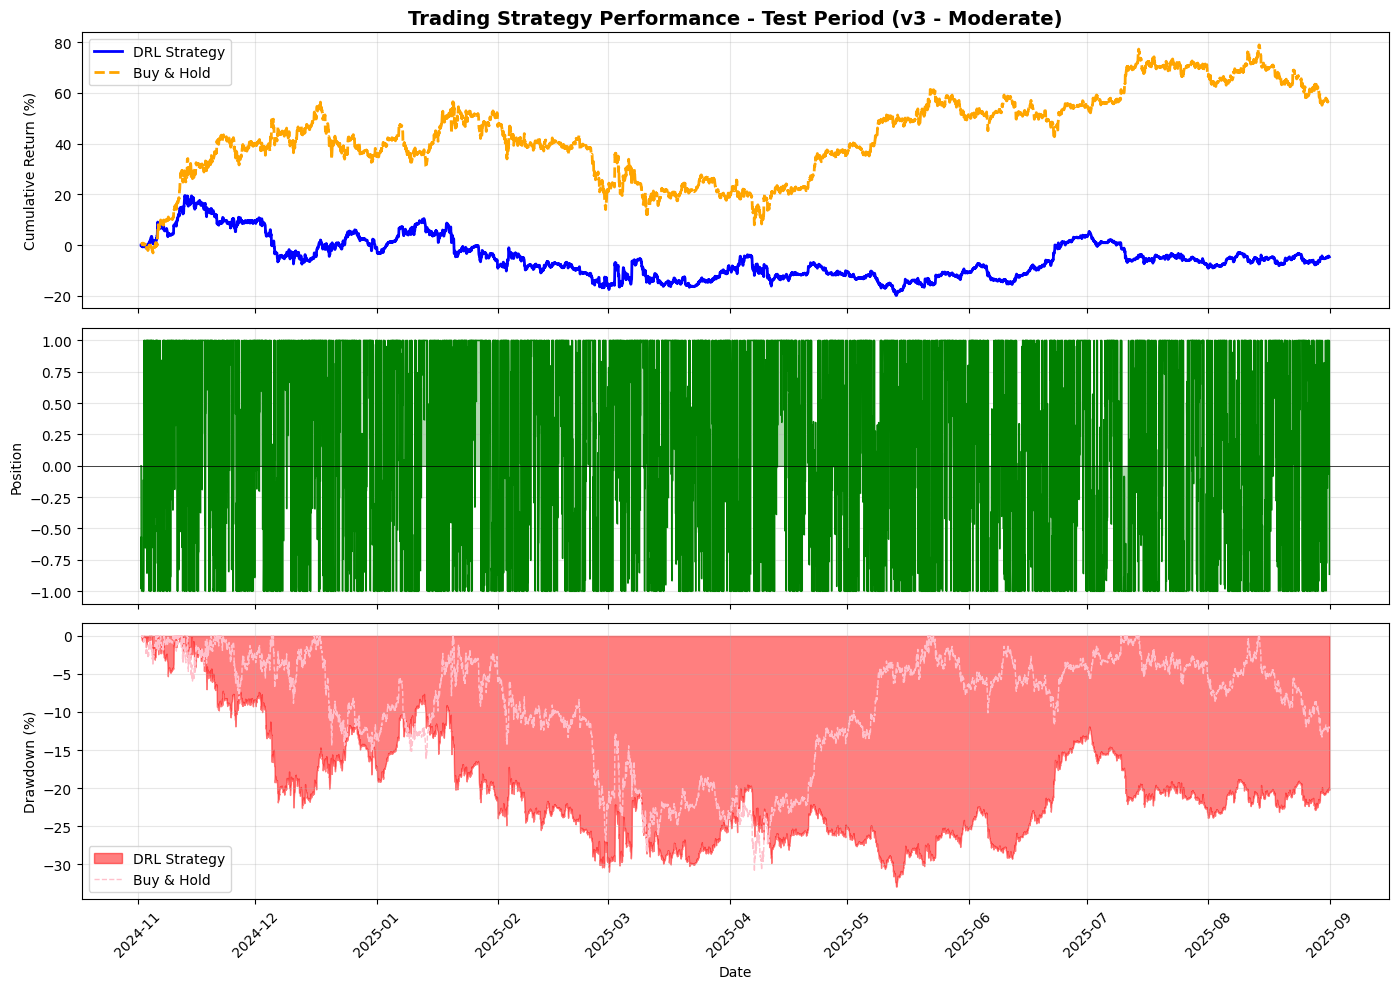


📊 Chart saved to: performance_chart_v3.png


In [29]:
# 累積リターン曲線
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Cumulative Returns', 'Position', 'Drawdown'),
    vertical_spacing=0.1,
    row_heights=[0.4, 0.3, 0.3]
)

# 時間軸
time_index = test_df.index[:len(strategy_results['nav_history'])]

# Buy & Hold NAVをDRL戦略と同じ長さに調整
bh_nav_aligned = bh_results['nav_history'][:len(strategy_results['nav_history'])]

# 1. 累積リターン
fig.add_trace(
    go.Scatter(
        x=time_index,
        y=(strategy_results['nav_history'] - 1) * 100,
        mode='lines',
        name='DRL Strategy',
        line=dict(color='blue', width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=(bh_nav_aligned - 1) * 100,
        mode='lines',
        name='Buy & Hold',
        line=dict(color='orange', width=2, dash='dash')
    ),
    row=1, col=1
)

# 2. ポジション（DRL戦略のみ）
fig.add_trace(
    go.Scatter(
        x=time_index,
        y=strategy_results['position_history'],
        mode='lines',
        name='Position',
        line=dict(color='green', width=1),
        fill='tozeroy',
        showlegend=False
    ),
    row=2, col=1
)

# 3. ドローダウン
strategy_cummax = np.maximum.accumulate(strategy_results['nav_history'])
strategy_dd = (strategy_results['nav_history'] - strategy_cummax) / strategy_cummax * 100

bh_cummax = np.maximum.accumulate(bh_nav_aligned)
bh_dd = (bh_nav_aligned - bh_cummax) / bh_cummax * 100

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=strategy_dd,
        mode='lines',
        name='DRL Drawdown',
        line=dict(color='red', width=1),
        fill='tozeroy',
        showlegend=False
    ),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=bh_dd,
        mode='lines',
        name='B&H Drawdown',
        line=dict(color='pink', width=1, dash='dash'),
        showlegend=False
    ),
    row=3, col=1
)

# レイアウト
fig.update_layout(
    title=f'DRL Trading Strategy Performance (v3 - {best_hyperparameters.name} Hyperparameters)',
    height=800,
    showlegend=True,
    hovermode='x unified'
)

fig.update_xaxes(title_text='Date', row=3, col=1)
fig.update_yaxes(title_text='Return (%)', row=1, col=1)
fig.update_yaxes(title_text='Position', row=2, col=1)
fig.update_yaxes(title_text='Drawdown (%)', row=3, col=1)

fig.show()

# 静的グラフ（matplotlib）
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 累積リターン
ax1 = axes[0]
ax1.plot(time_index, (strategy_results['nav_history'] - 1) * 100, label='DRL Strategy', color='blue', linewidth=2)
ax1.plot(time_index, (bh_nav_aligned - 1) * 100, label='Buy & Hold', color='orange', linestyle='--', linewidth=2)
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_title(f'Trading Strategy Performance - Test Period (v3 - {best_hyperparameters.name})', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# ポジション
ax2 = axes[1]
ax2.plot(time_index, strategy_results['position_history'], color='green', linewidth=1)
ax2.fill_between(time_index, strategy_results['position_history'], alpha=0.3, color='green')
ax2.set_ylabel('Position')
ax2.set_ylim(-1.1, 1.1)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# ドローダウン
ax3 = axes[2]
ax3.fill_between(time_index, strategy_dd, alpha=0.5, color='red', label='DRL Strategy')
ax3.plot(time_index, bh_dd, color='pink', linestyle='--', linewidth=1, label='Buy & Hold')
ax3.set_ylabel('Drawdown (%)')
ax3.set_xlabel('Date')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

# 保存
save_path = '/content/performance_chart_v3.png' if IN_COLAB else 'performance_chart_v3.png'
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📊 Chart saved to: {save_path}")

## 14. 最終サマリー

In [30]:
print("\n" + "="*80)
print("🎯 FINAL SUMMARY - Deep Reinforcement Learning Trading System v3")
print("="*80)

print("\n📊 Dataset:")
print(f"   Symbol: BTCUSDT Perpetual (Bybit)")
print(f"   Timeframe: 1 hour")
print(f"   Total period: {df_features.index[0]} to {df_features.index[-1]}")
print(f"   Train samples: {len(train_df):,}")
print(f"   Test samples: {len(test_df):,}")

print("\n🤖 Model:")
print(f"   Algorithm: PPO (Proximal Policy Optimization)")
print(f"   Hyperparameter Sets Tested: {len(HYPERPARAMETER_SETS)}")
print(f"   Selected Hyperparameters: {best_hyperparameters.name}")
print(f"   Walk-Forward steps: {len(wfo_splits)}")
print(f"   Features: {len(feature_columns)} (stationary & dimensionless)")
print(f"   Action space: Continuous [-1, +1]")

print("\n💰 Trading Parameters:")
print(f"   Initial capital: {INITIAL_CAPITAL}")
print(f"   Taker fee: {TAKER_FEE*100:.2f}%")
print(f"   Leverage: {LEVERAGE}x")
print(f"   Execution: {EXECUTION_PRICE}")

print("\n🏆 Test Period Results:")
print("\n   DRL Strategy:")
print(f"     - Total Return: {strategy_results['total_return']*100:+.2f}%")
print(f"     - Sharpe Ratio: {strategy_results['sharpe_ratio']:.3f}")
print(f"     - Max Drawdown: {strategy_results['max_drawdown']*100:.2f}%")
print(f"     - Calmar Ratio: {strategy_results['calmar_ratio']:.3f}")
print(f"     - Win Rate: {strategy_results['win_rate']*100:.1f}%")
print(f"     - Trades: {strategy_results['n_trades']}")

print("\n   Buy & Hold:")
print(f"     - Total Return: {bh_results['total_return']*100:+.2f}%")
print(f"     - Sharpe Ratio: {bh_results['sharpe_ratio']:.3f}")
print(f"     - Max Drawdown: {bh_results['max_drawdown']*100:.2f}%")
print(f"     - Calmar Ratio: {bh_results['calmar_ratio']:.3f}")

print("\n🎓 Key Improvements in v3:")
print("   1. Hyperparameter optimization with 3 different sets")
print("   2. Stationary and dimensionless features only")
print("   3. Proper data leakage prevention in scaling")
print("   4. Final model retrained on entire train set with best hyperparameters")

print("\n📁 Output Files:")
if IN_COLAB:
    print("   - /content/final_model_ppo.zip (trained model)")
    print("   - /content/final_scaler.pkl (feature scaler)")
    print("   - /content/performance_chart_v3.png")
else:
    print("   - final_model_ppo.zip (trained model)")
    print("   - final_scaler.pkl (feature scaler)")
    print("   - performance_chart_v3.png")

print("\n⚠️  Disclaimer:")
print("   This is for educational purposes only. Not financial advice.")
print("   Past performance does not guarantee future results.")
print("   Cryptocurrency trading involves substantial risk of loss.")

print("\n✅ Analysis Complete!")
print("="*80)


🎯 FINAL SUMMARY - Deep Reinforcement Learning Trading System v3

📊 Dataset:
   Symbol: BTCUSDT Perpetual (Bybit)
   Timeframe: 1 hour
   Total period: 2020-09-08 01:00:00+00:00 to 2025-08-31 23:00:00+00:00
   Train samples: 36,379
   Test samples: 7,276

🤖 Model:
   Algorithm: PPO (Proximal Policy Optimization)
   Hyperparameter Sets Tested: 3
   Selected Hyperparameters: Moderate
   Walk-Forward steps: 4
   Features: 32 (stationary & dimensionless)
   Action space: Continuous [-1, +1]

💰 Trading Parameters:
   Initial capital: 1.0
   Taker fee: 0.00%
   Leverage: 1.0x
   Execution: next_open

🏆 Test Period Results:

   DRL Strategy:
     - Total Return: -4.64%
     - Sharpe Ratio: 0.073
     - Max Drawdown: -32.95%
     - Calmar Ratio: -0.169
     - Win Rate: 50.8%
     - Trades: 5002

   Buy & Hold:
     - Total Return: +56.25%
     - Sharpe Ratio: 1.366
     - Max Drawdown: -30.98%
     - Calmar Ratio: 2.296

🎓 Key Improvements in v3:
   1. Hyperparameter optimization with 3 differ